In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Energy_consumption.csv')
df.head(3)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888


In [22]:
data = df.copy()
data.info()
print('DataSet Shape :',data.shape)
print('Columns : ',data.columns)

data.isna().sum()
data.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB
DataSet Shape : (1000, 11)
Columns :  Index(['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday',
       'Ener

np.int64(0)

In [23]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

data['Hour'] = data['Timestamp'].dt.hour
data['Month'] = data['Timestamp'].dt.month
data['Day'] = data['Timestamp'].dt.day

data['Temp_per_Occupancy'] = data['Temperature'] * data['Occupancy']

In [24]:
data.head(3)
data.columns

Index(['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday',
       'EnergyConsumption', 'Hour', 'Month', 'Day', 'Temp_per_Occupancy'],
      dtype='object')

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['DayOfWeek'] = le.fit_transform(data['DayOfWeek'])

In [26]:
data = pd.get_dummies(data,columns=['HVACUsage','LightingUsage','Holiday'],drop_first=True)

In [27]:
import numpy as np

# Hour (Cycle of 24)
data['hour_sin'] = np.sin(2 * np.pi * data['Hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['Hour'] / 24)

# Month (Cycle of 12)
data['month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)

# Day of Month (Cycle of 31 - approximate)
data['day_sin'] = np.sin(2 * np.pi * data['Day'] / 31)
data['day_cos'] = np.cos(2 * np.pi * data['Day'] / 31)

# Now safe to drop the linear versions
data = data.drop(columns=['Hour', 'Month', 'Day'])

In [28]:
data.head(3)

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the dataframe
    df_outliers_removed = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_outliers_removed

# Apply to your main columns
data = remove_outliers(data, 'EnergyConsumption')
data = remove_outliers(data, 'Temperature')

print(f"New dataset size: {data.shape[0]} rows")

New dataset size: 999 rows


In [29]:
X = data.drop(columns=['Timestamp','EnergyConsumption','Holiday_Yes'])
y = data['EnergyConsumption']

In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
print(len(X_train.columns))
X_train

15


,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,DayOfWeek,Temp_per_Occupancy,HVACUsage_On,LightingUsage_On,hour_sin,hour_cos,month_sin,month_cos,day_sin,day_cos
779,23.926435,56.132832,1923.904182,0,24.314704,5,0.000000,False,False,0.258819,-0.965926,0.866025,0.500000,0.394356,0.918958
287,24.223266,49.208162,1228.296923,2,0.251475,2,48.446533,False,True,-0.258819,0.965926,0.500000,0.866025,0.651372,-0.758758
166,26.074942,35.517321,1531.885316,6,6.319201,4,156.449649,False,True,-0.500000,0.866025,0.500000,0.866025,0.988468,0.151428
961,24.191475,46.789444,1391.984705,7,11.095044,5,169.340323,False,True,0.258819,0.965926,0.866025,0.500000,0.897805,-0.440394
494,21.932235,32.233208,1680.820433,4,10.380601,3,87.728938,False,False,-0.500000,-0.866025,0.500000,0.866025,-0.897805,-0.440394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,22.779637,58.580186,1226.318727,1,25.210074,1,22.779637,False,False,0.258819,-0.965926,0.500000,0.866025,0.848644,0.528964
271,24.600722,43.646227,1854.877725,7,16.995707,3,172.205052,False,True,0.965926,-0.258819,0.500000,0.866025,0.651372,-0.758758
861,21.096890,47.197906,1353.003219,9,28.517626,0,189.872007,True,True,-0.707107,0.707107,0.866025,0.500000,0.848644,0.528964
436,29.132278,50.810242,1693.758951,9,11.834462,5,262.190506,True,False,0.866025,0.500000,0.500000,0.866025,-0.651372,-0.758758


In [32]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [13]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score
# from sklearn.model_selection import GridSearchCV

# model = RandomForestRegressor(n_estimators=100) # 54%
# # model.fit(X_train,y_train)

# param={
#     "n_estimators":[100,200],
#     "max_depth":[5,10,None],
#     "min_samples_split":[2,5]
# }

# grid = GridSearchCV(model,param,cv=5,scoring='r2')
# grid.fit(X_train,y_train)

# print(grid.best_params_)
# print(grid.best_score_)

# y_pred = grid.predict(X_test)
# print('R2 score :',r2_score(y_test,y_pred))

In [33]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

model_r = Ridge()

params = {
    'alpha': [0.1, 1.0, 10.0, 100.0], # This is the "strength" of regularization
    'fit_intercept': [True, False]
}

grid = GridSearchCV(model_r, params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

y_pred = grid.predict(X_test)
print('R2 score :',r2_score(y_test,y_pred))

{'alpha': 10.0, 'fit_intercept': True}
0.5990312506062254
R2 score : 0.5821276507288136


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

model = LinearRegression() # 59%

# model.fit(X_train_final,y_train)
# y_pred = model.predict(X_test_final)
# print('R2 score :',r2_score(y_test,y_pred))

params = {
    'fit_intercept':[True,False],
    'positive':[True,False]
}

grid_l = GridSearchCV(model,params,cv=5)

grid_l.fit(X_train,y_train)

print(grid_l.best_params_)
print(grid_l.best_score_)

y_pred = grid_l.predict(X_test)

print('R2 score :',r2_score(y_test,y_pred))
print('Mae:',mean_absolute_error(y_test,y_pred))
print('Mse:',mean_squared_error(y_test,y_pred))

{'fit_intercept': True, 'positive': True}
0.6014246412351003
R2 score : 0.582359767306054
Mae: 3.986598083237833
Mse: 25.763051422872568


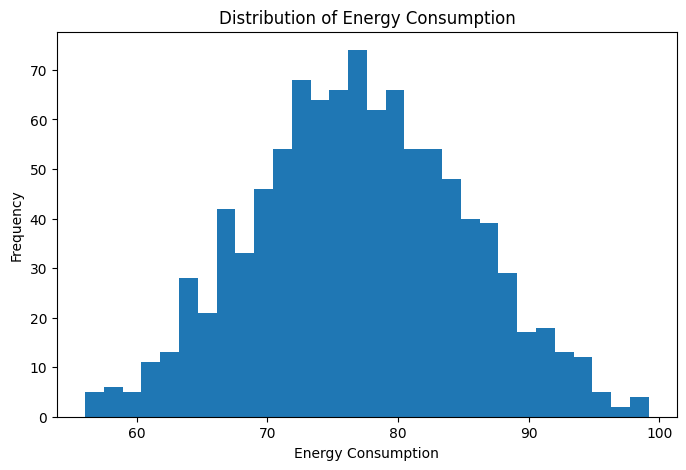

In [35]:
plt.figure(figsize=(8,5))
plt.hist(data['EnergyConsumption'], bins=30)

plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption")
plt.ylabel("Frequency")

plt.show()

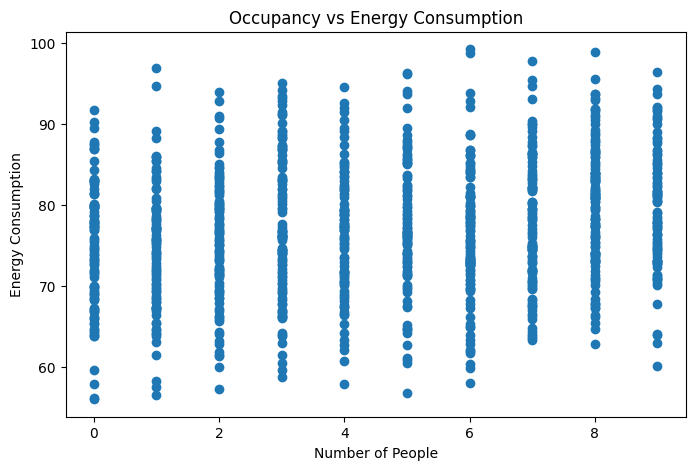

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(x=data['Occupancy'], y=data['EnergyConsumption'])

plt.title("Occupancy vs Energy Consumption")
plt.xlabel("Number of People")
plt.ylabel("Energy Consumption")

plt.show()

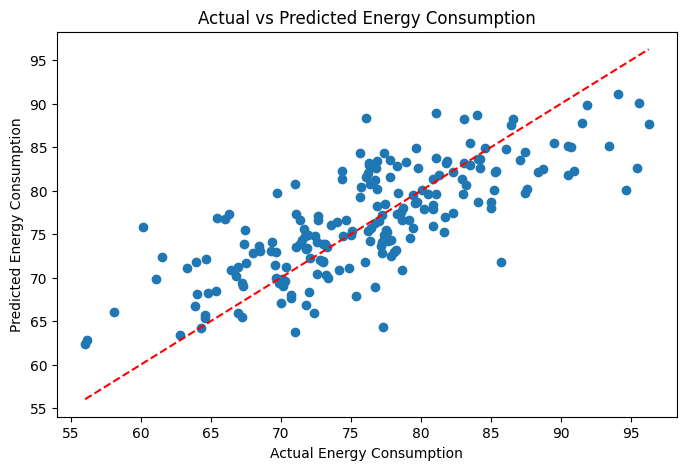

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [19]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
# plt.title("Feature Correlation Heatmap")
# plt.show()

In [38]:
import joblib

# Save the best model from your GridSearch
joblib.dump(grid.best_estimator_, 'energy_model.joblib')
joblib.dump(ss,'scaler.joblib')

['scaler.joblib']